# Adaptive Fraud Detection with Dynamic Thresholding and Cost-Sensitive Learning

**EE559 (CSCI 559) — Midway Progress Report** 
**Student:** Om Suresh Prajapati &nbsp;|&nbsp; **USC ID:** 1430823821 &nbsp;|&nbsp; **Date:** April 13, 2026

---

> **Abstract:** This notebook presents the midway progress for a supervised ML pipeline for credit card fraud
> detection. We perform exploratory data analysis (EDA) on the Kaggle Credit Card Fraud Detection dataset,
> implement a leakage-free preprocessing pipeline, and evaluate two baseline classifiers — Logistic Regression
> and Random Forest — using metrics appropriate for highly imbalanced classification tasks.

## Table of Contents

1. [Setup and Dependencies](#1.-Setup-and-Dependencies)
2. [Data Loading](#2.-Data-Loading)
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
   - 3.1 Dataset Overview
   - 3.2 Class Distribution
   - 3.3 Time and Amount Features
   - 3.4 Feature Correlation Analysis
   - 3.5 Top Feature Distributions
4. [Data Preprocessing](#4.-Data-Preprocessing)
   - 4.1 Train / Validation / Test Split
   - 4.2 Feature Scaling
5. [Baseline Models](#5.-Baseline-Models)
   - 5.1 Logistic Regression
   - 5.2 Random Forest
6. [Model Comparison](#6.-Model-Comparison)
7. [Summary and Next Steps](#7.-Summary-and-Next-Steps)

---
## 1. Setup and Dependencies

We import all required libraries here and set global constants for reproducibility.
A fixed `RANDOM_STATE = 42` is passed to every stochastic function so that anyone who
runs this notebook gets identical results.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

# ── Global settings ──────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Ensure output directory exists
os.makedirs('../reports/figures', exist_ok=True)

# ── Version check ─────────────────────────────────────────────────────────────
import sklearn
print(f'numpy        : {np.__version__}')
print(f'pandas       : {pd.__version__}')
print(f'scikit-learn : {sklearn.__version__}')
print(f'matplotlib   : {matplotlib.__version__}')
print(f'seaborn      : {sns.__version__}')
print('All libraries loaded successfully.')

numpy        : 2.4.4
pandas       : 3.0.2
scikit-learn : 1.8.0
matplotlib   : 3.10.8
seaborn      : 0.13.2
All libraries loaded successfully.


---
## 2. Data Loading

The dataset is the **Kaggle Credit Card Fraud Detection** dataset. It contains 284,807 credit
card transactions made by European cardholders in September 2013.

- **Features V1–V28**: The result of a PCA transformation applied to protect user privacy.
  The original features are not disclosed.
- **Time**: Seconds elapsed between this transaction and the first transaction in the dataset.
- **Amount**: The transaction amount in Euros.
- **Class**: The target label — `1` for fraud, `0` for legitimate.

In [22]:
DATA_PATH = '../data/creditcard.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape : {df.shape}  (rows x columns)')
print(f'Columns       : {list(df.columns)}')
print()
df.head()

Dataset shape : (284807, 31)  (rows x columns)
Columns       : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 3. Exploratory Data Analysis

Before building any model, we need to deeply understand the data: its structure,
the severity of class imbalance, and which features might carry discriminative power.
This section will also reveal any data quality issues (missing values, outliers) that
must be addressed in preprocessing.

### 3.1 Dataset Overview

We start with a structural inspection: shape, data types, missing values, and
basic statistics. Finding zero missing values here means we do not need any
imputation strategy — a relatively rare luxury in real-world data.

In [23]:
print('=' * 50)
print('  DATASET STRUCTURAL OVERVIEW')
print('=' * 50)
print(f'Total transactions  : {len(df):,}')
print(f'Total features      : {df.shape[1] - 1}  (V1-V28, Time, Amount)')
print(f'Target column       : Class')
print(f'Missing values      : {df.isnull().sum().sum()}')
print(f'Duplicate rows      : {df.duplicated().sum():,}')
print()
print('Data types:')
print(df.dtypes.value_counts().to_string())
print()
print('Summary statistics for Time and Amount (unscaled originals):')
df[['Time', 'Amount']].describe().round(2)

  DATASET STRUCTURAL OVERVIEW
Total transactions  : 284,807
Total features      : 30  (V1-V28, Time, Amount)
Target column       : Class
Missing values      : 0
Duplicate rows      : 1,081

Data types:
float64    30
int64       1

Summary statistics for Time and Amount (unscaled originals):


,Time,Amount
count,284807.00,284807.00
mean,94813.86,88.35
std,47488.15,250.12
min,0.00,0.00
25%,54201.50,5.60
50%,84692.00,22.00
75%,139320.50,77.16
max,172792.00,25691.16


### 3.2 Class Distribution

The central challenge of this dataset is **severe class imbalance**: only 492 out of
284,807 transactions are fraudulent (~0.17%). This has two major consequences:

1. **Accuracy is misleading** — a model that labels every transaction as legitimate achieves
   99.83% accuracy while completely failing at fraud detection.
2. **Standard training is biased** — without correction, classifiers will optimize toward the
   majority class and essentially ignore fraud.

We address consequence (1) by using **Precision-Recall AUC** and **ROC-AUC** as primary metrics.
We address consequence (2) by using `class_weight='balanced'` in both models.

In [24]:
counts = df['Class'].value_counts().sort_index()
print('=' * 50)
print('  CLASS DISTRIBUTION')
print('=' * 50)
print(f'Legitimate (0) : {counts[0]:,}  ({counts[0]/len(df)*100:.3f}%)')
print(f'Fraudulent (1) : {counts[1]:,}   ({counts[1]/len(df)*100:.3f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.0f} : 1')
print()
print('A naive classifier predicting ALL as legitimate would achieve:')
print(f'  Accuracy = {counts[0]/len(df)*100:.2f}%  —  completely useless for fraud detection.')

  CLASS DISTRIBUTION
Legitimate (0) : 284,315  (99.827%)
Fraudulent (1) : 492   (0.173%)
Imbalance ratio: 578 : 1

A naive classifier predicting ALL as legitimate would achieve:
  Accuracy = 99.83%  —  completely useless for fraud detection.


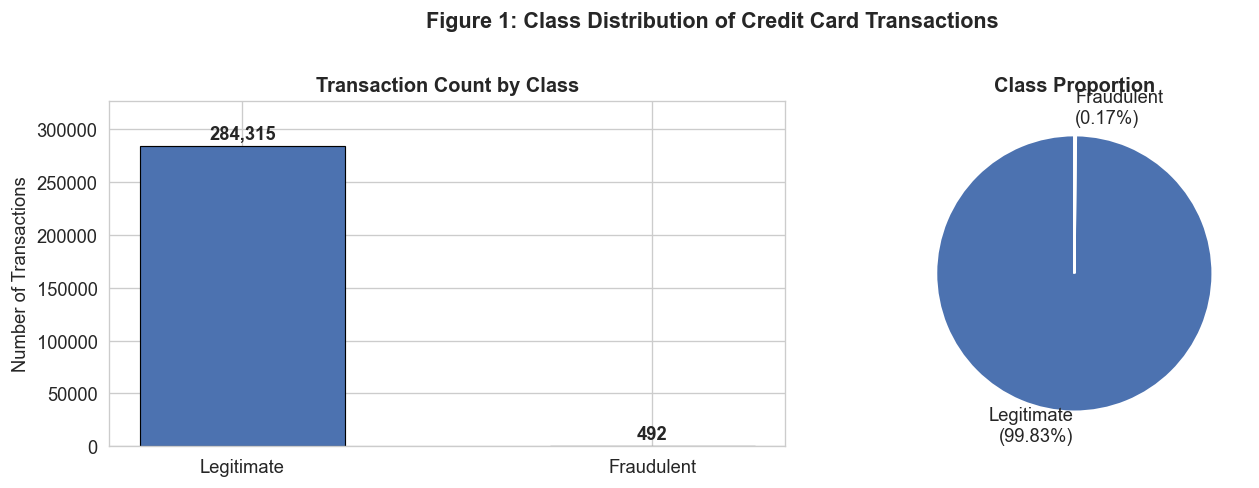

Figure 1 saved.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_colors = ['#4C72B0', '#C44E52']

# ── Bar chart ──────────────────────────────────────────────────────────────
bars = axes[0].bar(
    ['Legitimate', 'Fraudulent'],
    [counts[0], counts[1]],
    color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5
)
axes[0].set_title('Transaction Count by Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_ylim(0, counts[0] * 1.15)
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2500,
        f'{val:,}', ha='center', va='bottom', fontweight='bold'
    )

# ── Pie chart ──────────────────────────────────────────────────────────────
axes[1].pie(
    [counts[0], counts[1]],
    labels=['Legitimate\n(99.83%)', 'Fraudulent\n(0.17%)'],
    colors=bar_colors,
    startangle=90,
    explode=(0, 0.1),
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold')

fig.suptitle('Figure 1: Class Distribution of Credit Card Transactions',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/fig_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

### 3.3 Time and Amount Features

Unlike V1–V28, the `Time` and `Amount` features are in their original (unscaled) units.

- **Time** spans approximately 48 hours of transaction data. Plotting it by class can reveal
  whether fraud clusters at particular times of day.
- **Amount** is the euro value of each transaction. Fraudulent transactions tend to cluster
  at smaller amounts — fraudsters often test cards with small charges before larger ones.

Because these features have different scales than V1–V28, they will require **StandardScaler**
normalization before being fed into distance- or gradient-sensitive models like Logistic Regression.

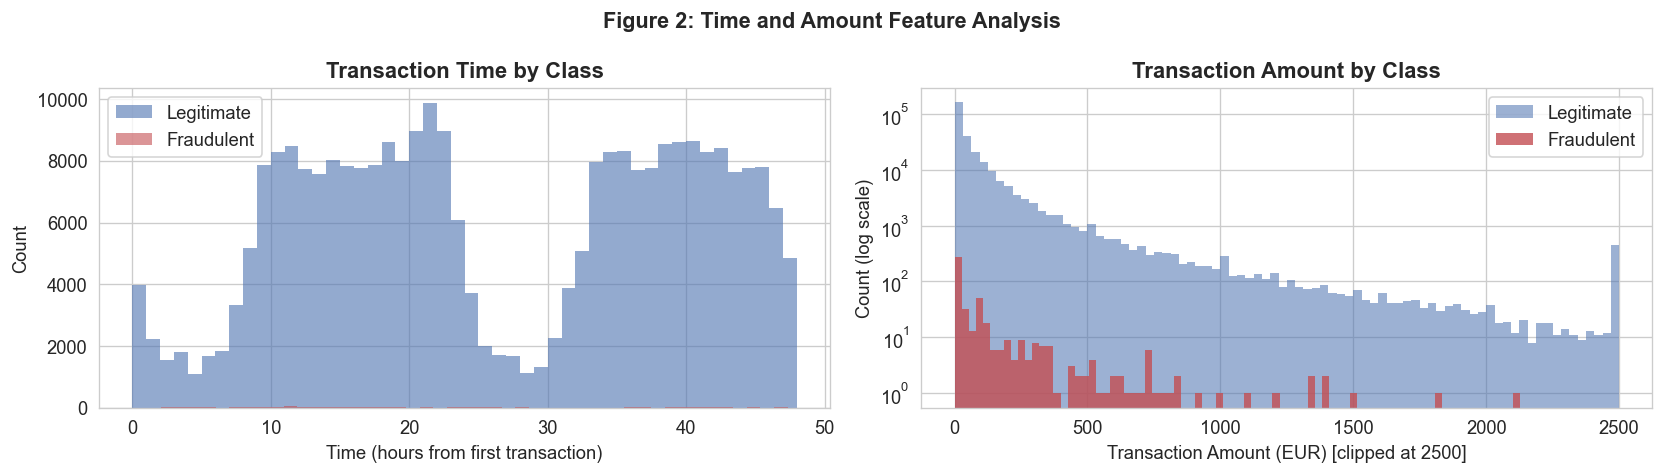

Amount statistics:
  Legitimate — Mean: 88.29 EUR | Median: 22.00 EUR | Max: 25691.16 EUR
  Fraudulent — Mean: 122.21 EUR | Median: 9.25 EUR | Max: 2125.87 EUR
Figure 2 saved.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = {'Legitimate': '#4C72B0', 'Fraudulent': '#C44E52'}

# ── Time distribution ──────────────────────────────────────────────────────
for cls, label, color in [(0, 'Legitimate', colors['Legitimate']),
                           (1, 'Fraudulent', colors['Fraudulent'])]:
    hours = df[df['Class'] == cls]['Time'] / 3600
    axes[0].hist(hours, bins=48, alpha=0.6, label=label, color=color, edgecolor='none')
axes[0].set_xlabel('Time (hours from first transaction)')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Time by Class', fontweight='bold')
axes[0].legend()

# ── Amount distribution (log scale) ──────────────────────────────────────
df_legit = df[df['Class'] == 0]['Amount']
df_fraud = df[df['Class'] == 1]['Amount']
axes[1].hist(df_legit.clip(upper=2500), bins=80, alpha=0.55,
             color=colors['Legitimate'], label='Legitimate', edgecolor='none')
axes[1].hist(df_fraud.clip(upper=2500), bins=80, alpha=0.8,
             color=colors['Fraudulent'], label='Fraudulent', edgecolor='none')
axes[1].set_xlabel('Transaction Amount (EUR) [clipped at 2500]')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Transaction Amount by Class', fontweight='bold')
axes[1].legend()

fig.suptitle('Figure 2: Time and Amount Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_02_time_amount.png', dpi=150, bbox_inches='tight')
plt.show()

print('Amount statistics:')
print(f'  Legitimate — Mean: {df_legit.mean():.2f} EUR | Median: {df_legit.median():.2f} EUR | Max: {df_legit.max():.2f} EUR')
print(f'  Fraudulent — Mean: {df_fraud.mean():.2f} EUR | Median: {df_fraud.median():.2f} EUR | Max: {df_fraud.max():.2f} EUR')
print('Figure 2 saved.')

### 3.4 Feature Correlation Analysis

We compute the absolute Pearson correlation of every feature with the binary target `Class`.
This is a fast linear screening technique that tells us which features have the strongest
*direct* relationship with fraud.

> **Note:** V1–V28 are PCA components and are already uncorrelated with each other by construction,
> so there is no multicollinearity to worry about. High correlation with the target here means the
> PCA component has captured variation that separates fraud from legitimate transactions.

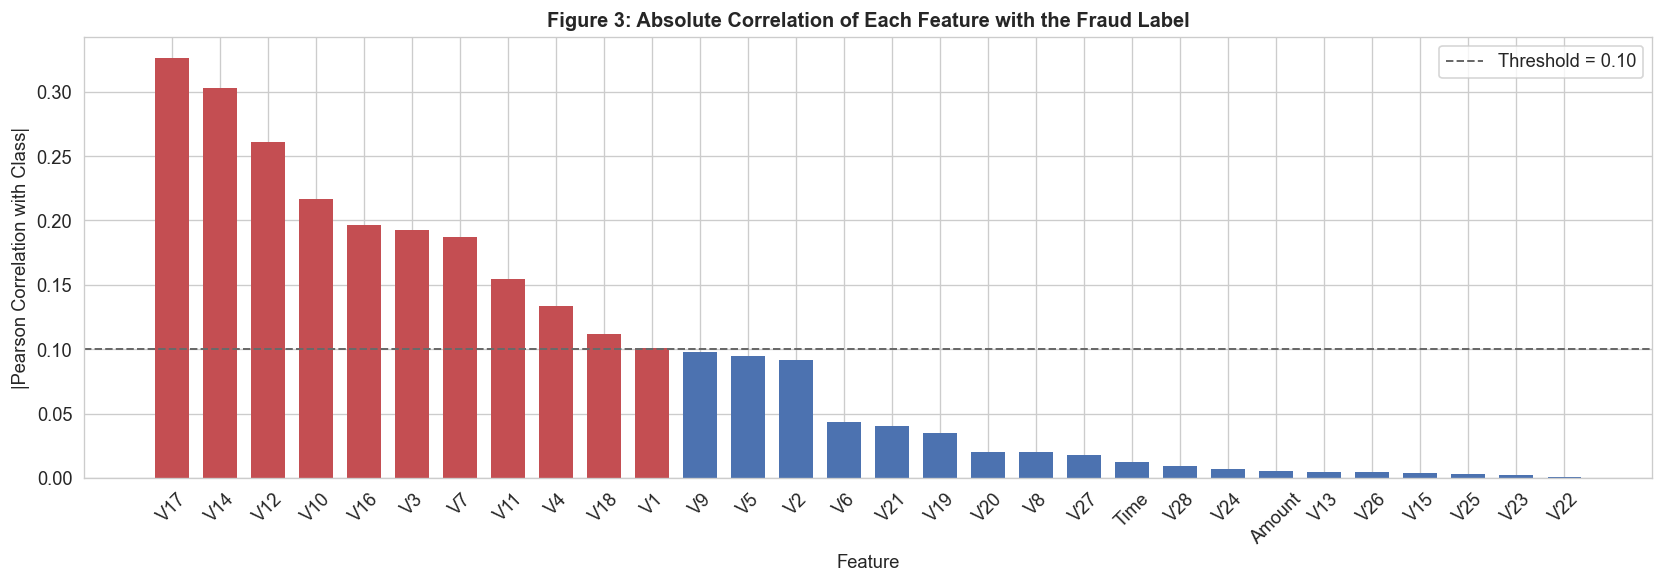

Top 8 features by |correlation|:
  V17        0.3265
  V14        0.3025
  V12        0.2606
  V10        0.2169
  V16        0.1965
  V3         0.1930
  V7         0.1873
  V11        0.1549
Figure 3 saved.


In [27]:
correlations = df.drop('Class', axis=1).corrwith(df['Class']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bar_cols = ['#C44E52' if v > 0.10 else '#4C72B0' for v in correlations.values]
ax.bar(correlations.index, correlations.values, color=bar_cols, edgecolor='none', width=0.7)
ax.axhline(y=0.10, color='dimgray', linestyle='--', linewidth=1.2, label='Threshold = 0.10')
ax.set_xlabel('Feature')
ax.set_ylabel('|Pearson Correlation with Class|')
ax.set_title('Figure 3: Absolute Correlation of Each Feature with the Fraud Label',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/fig_03_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

TOP_K = 8
top_features = correlations.head(TOP_K).index.tolist()
print(f'Top {TOP_K} features by |correlation|:')
for feat, corr in correlations.head(TOP_K).items():
    print(f'  {feat:<10} {corr:.4f}')
print('Figure 3 saved.')

### 3.5 Top Feature Distributions: Fraud vs. Legitimate

For the top 6 features by correlation, we plot overlapping density histograms for both classes.
Features where the two distributions **barely overlap** will be the most useful discriminators.
Features with almost identical distributions for both classes will contribute little signal.

This informs us about how hard the classification problem is — if every feature overlaps heavily,
we expect lower precision regardless of model choice.

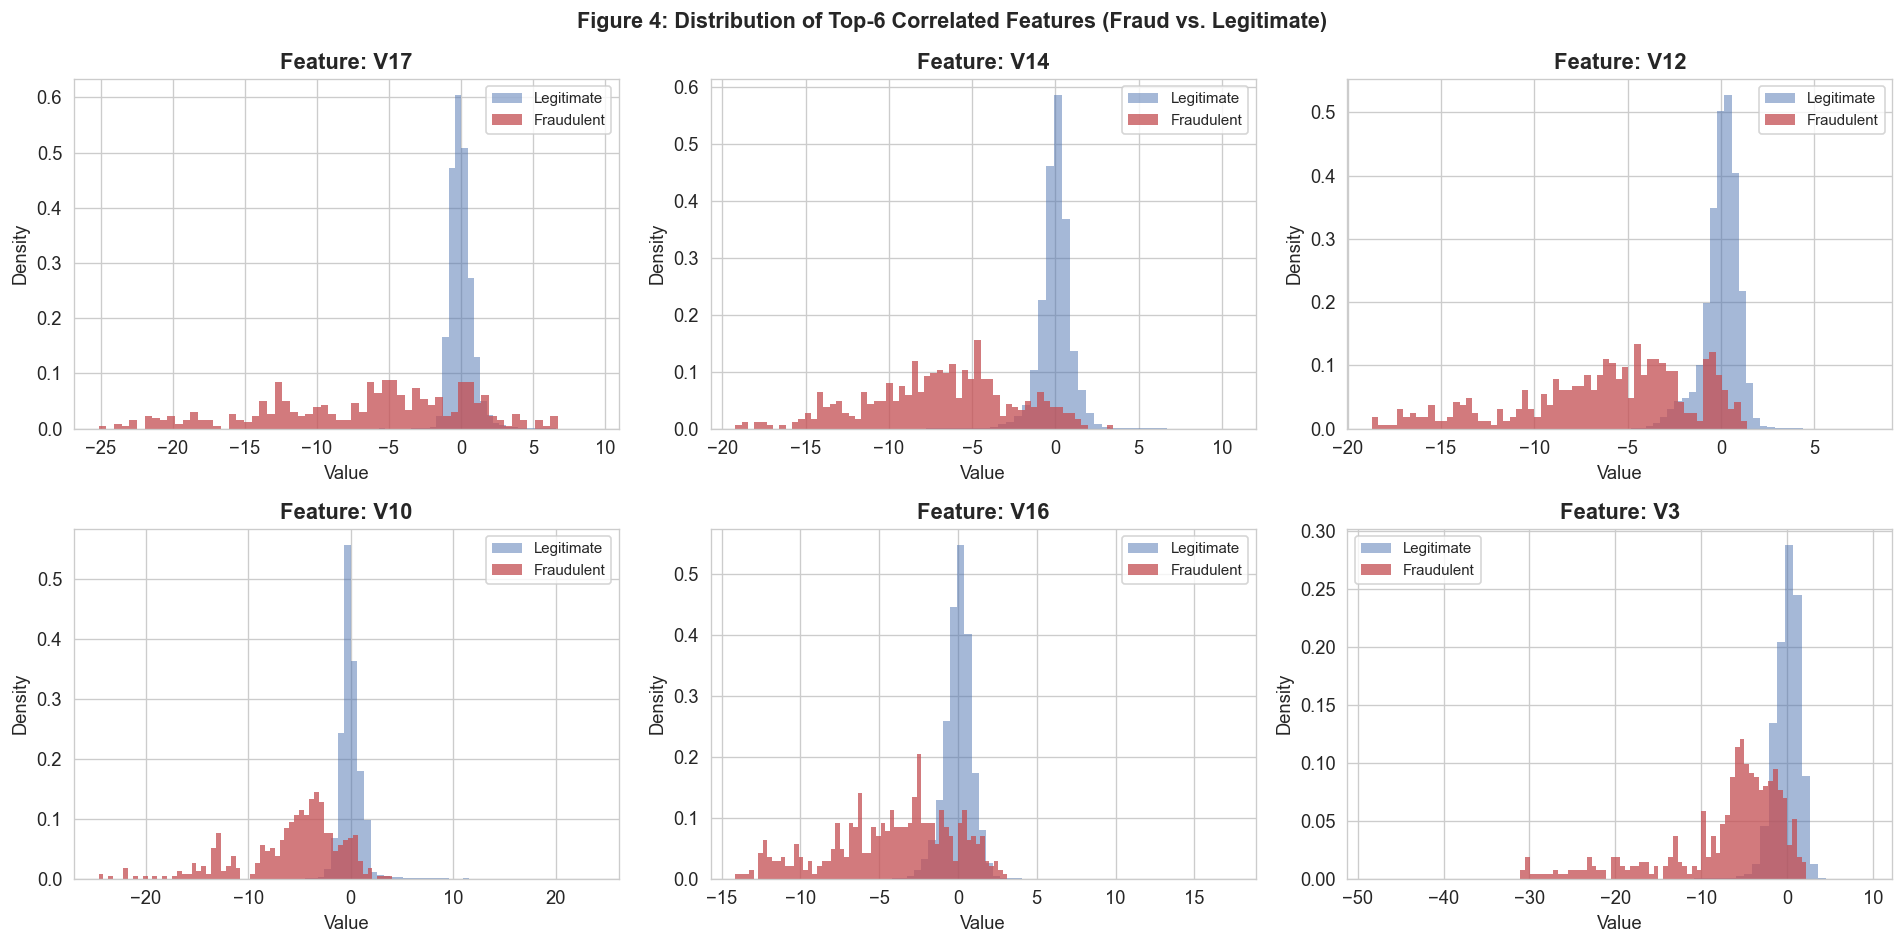

Figure 4 saved.


In [28]:
top_6 = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_6):
    legit_vals = df[df['Class'] == 0][feat]
    fraud_vals = df[df['Class'] == 1][feat]

    axes[i].hist(legit_vals, bins=60, alpha=0.5, color='#4C72B0',
                 label='Legitimate', density=True, edgecolor='none')
    axes[i].hist(fraud_vals, bins=60, alpha=0.75, color='#C44E52',
                 label='Fraudulent', density=True, edgecolor='none')
    axes[i].set_title(f'Feature: {feat}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

fig.suptitle('Figure 4: Distribution of Top-6 Correlated Features (Fraud vs. Legitimate)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_04_top_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## 4. Data Preprocessing

A clean, leakage-free preprocessing pipeline is critical for valid model evaluation.
We follow this strict order:

```
1. Split data  →  2. Fit scaler on TRAIN only  →  3. Transform train / val / test
```

Fitting the scaler on the full dataset would **leak** test-set statistics into training,
producing artificially optimistic results that do not reflect real-world performance.
For the midway report, no resampling (SMOTE, under-sampling) is applied — these are
reserved for the final model refinement phase.

### 4.1 Train / Validation / Test Split

We use a **70% / 15% / 15%** stratified split. Stratification ensures the same fraud
prevalence (~0.17%) is preserved in every split — without it, we might accidentally
place very few or zero fraud cases in the validation set.

In [29]:
X = df.drop('Class', axis=1)
y = df['Class']

# Step 1: hold out 15% as test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Step 2: from remaining 85%, hold out ~17.65% as validation (= 15% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_temp
)

print('=' * 55)
print(f'  SPLIT SUMMARY  (total = {len(df):,})')
print('=' * 55)
for split_name, X_s, y_s in [('Train', X_train, y_train),
                               ('Validation', X_val, y_val),
                               ('Test', X_test, y_test)]:
    n_fraud = y_s.sum()
    pct = len(X_s) / len(df) * 100
    print(f'{split_name:<12} : {len(X_s):,} samples ({pct:.1f}%) | '
          f'Fraud: {n_fraud} ({n_fraud/len(y_s)*100:.3f}%)')
print()
print('Stratification verified: fraud prevalence is ~0.17% in all three splits.')

  SPLIT SUMMARY  (total = 284,807)
Train        : 199,356 samples (70.0%) | Fraud: 344 (0.173%)
Validation   : 42,729 samples (15.0%) | Fraud: 74 (0.173%)
Test         : 42,722 samples (15.0%) | Fraud: 74 (0.173%)

Stratification verified: fraud prevalence is ~0.17% in all three splits.


### 4.2 Feature Scaling

We apply `StandardScaler` (zero mean, unit variance) to **only** the `Time` and `Amount` columns.

**Why not scale V1–V28?**  
Features V1–V28 are the output of PCA, which inherently produces zero-mean, decorrelated components.
They are already on a comparable scale. Re-scaling them would be redundant and could slightly
distort their relative magnitudes.

**Critical rule:** The scaler is `fit()` only on `X_train`. We then `transform()` the validation
and test sets using the *training* scaler. This is mandatory to prevent data leakage.

In [30]:
COLS_TO_SCALE = ['Time', 'Amount']

scaler = StandardScaler()

X_train_sc = X_train.copy()
X_val_sc   = X_val.copy()
X_test_sc  = X_test.copy()

# Fit ONLY on training data, then apply the same transform to val and test
X_train_sc[COLS_TO_SCALE] = scaler.fit_transform(X_train[COLS_TO_SCALE])
X_val_sc[COLS_TO_SCALE]   = scaler.transform(X_val[COLS_TO_SCALE])
X_test_sc[COLS_TO_SCALE]  = scaler.transform(X_test[COLS_TO_SCALE])

print(f'Scaler fitted on training set only.')
print(f'Columns scaled : {COLS_TO_SCALE}')
print()
print('After scaling — training set statistics (should be ~0 mean, ~1 std):')
print(X_train_sc[COLS_TO_SCALE].describe().loc[['mean', 'std']].round(4).to_string())
print()
print('Validation set (will differ slightly — scaler was NOT re-fitted here):')
print(X_val_sc[COLS_TO_SCALE].describe().loc[['mean', 'std']].round(4).to_string())

Scaler fitted on training set only.
Columns scaled : ['Time', 'Amount']

After scaling — training set statistics (should be ~0 mean, ~1 std):
      Time  Amount
mean  -0.0    -0.0
std    1.0     1.0

Validation set (will differ slightly — scaler was NOT re-fitted here):
        Time  Amount
mean -0.0074  0.0010
std   0.9968  1.0354


---
## 5. Baseline Models

We evaluate two models on the **validation set**. The test set is held out and will only
be used for the final evaluation in the complete project.

**Primary metrics** (appropriate for imbalanced data):
- **PR-AUC** (Precision-Recall Area Under Curve): measures how well the model balances
  precision and recall across all thresholds. More informative than ROC-AUC when positives
  are rare.
- **ROC-AUC**: measures the model's ability to rank a random fraud above a random legitimate
  transaction. Useful for comparison but can be overly optimistic on imbalanced data.

**Secondary metrics**: Precision, Recall, F1-score, and Confusion Matrix — all at the
default decision threshold of 0.50 for now.

In [31]:
def evaluate_model(model, X_val, y_val, model_name):
    """
    Evaluates a trained classifier on the validation set.
    Returns: (y_pred, y_prob, roc_auc, pr_auc)
    """
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc  = average_precision_score(y_val, y_prob)
    report  = classification_report(y_val, y_pred,
                                     target_names=['Legitimate', 'Fraudulent'],
                                     digits=4)

    print(f'\n{"=" * 60}')
    print(f'  {model_name} — Validation Set Results')
    print(f'{"=" * 60}')
    print(report)
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(f'  PR-AUC   : {pr_auc:.4f}')
    print(f'{"=" * 60}')

    return y_pred, y_prob, roc_auc, pr_auc


def plot_evaluation(y_val, y_pred, y_prob, model_name, fig_prefix):
    """
    Plots confusion matrix, ROC curve, and Precision-Recall curve side by side.
    Saves the figure to reports/figures/.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Confusion Matrix ─────────────────────────────────────────────────────
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraudulent']).plot(
        ax=axes[0], colorbar=False, cmap='Blues'
    )
    axes[0].set_title(f'Confusion Matrix', fontweight='bold')

    # ── ROC Curve ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = roc_auc_score(y_val, y_prob)
    axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)

    # ── Precision-Recall Curve ────────────────────────────────────────────────
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)
    baseline = y_val.mean()
    axes[2].plot(recall, precision, color='#C44E52', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].axhline(y=baseline, color='gray', linestyle='--', lw=1,
                    label=f'Baseline = {baseline:.4f}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve', fontweight='bold')
    axes[2].legend(fontsize=9)

    fig.suptitle(f'{model_name} — Evaluation on Validation Set',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = f'../reports/figures/{fig_prefix}_evaluation.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {save_path}')


print('Helper functions defined: evaluate_model(), plot_evaluation()')

Helper functions defined: evaluate_model(), plot_evaluation()


### 5.1 Logistic Regression

Logistic Regression is our **linear baseline**. It models the log-odds of fraud as a
linear combination of input features:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1+e^{-(\mathbf{w}^\top \mathbf{x}+b)}}$$

**Key choices:**
- **`penalty='l2'`**: L2 (Ridge) regularization. Penalizes large weights by adding
  $\lambda \|\mathbf{w}\|_2^2$ to the loss, which reduces overfitting and handles
  correlated features.
- **`C=1.0`**: Inverse regularization strength. Lower C = stronger regularization.
  We keep the default for the baseline; we will tune it in the final project.
- **`class_weight='balanced'`**: Scikit-learn automatically sets the weight of class $c$
  to $\frac{N}{2 \cdot N_c}$, where $N_c$ is the count of class $c$. This gives the
  rare fraud class ~577× more weight in the loss function, countering the imbalance.

In [32]:
lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)
print('Logistic Regression trained successfully.')
print(f'  Penalty        : L2   (C = {lr.C})')
print(f'  Class weight   : balanced')
print(f'  Solver         : lbfgs')
print(f'  Max iterations : {lr.max_iter} (converged = {lr.n_iter_[0] < lr.max_iter})')

Logistic Regression trained successfully.
  Penalty        : L2   (C = 1.0)
  Class weight   : balanced
  Solver         : lbfgs
  Max iterations : 1000 (converged = True)


In [33]:
lr_pred, lr_prob, lr_roc, lr_pr = evaluate_model(lr, X_val_sc, y_val, 'Logistic Regression')


  Logistic Regression — Validation Set Results
              precision    recall  f1-score   support

  Legitimate     0.9999    0.9781    0.9889     42655
  Fraudulent     0.0679    0.9189    0.1265        74

    accuracy                         0.9780     42729
   macro avg     0.5339    0.9485    0.5577     42729
weighted avg     0.9982    0.9780    0.9874     42729

  ROC-AUC  : 0.9860
  PR-AUC   : 0.7520


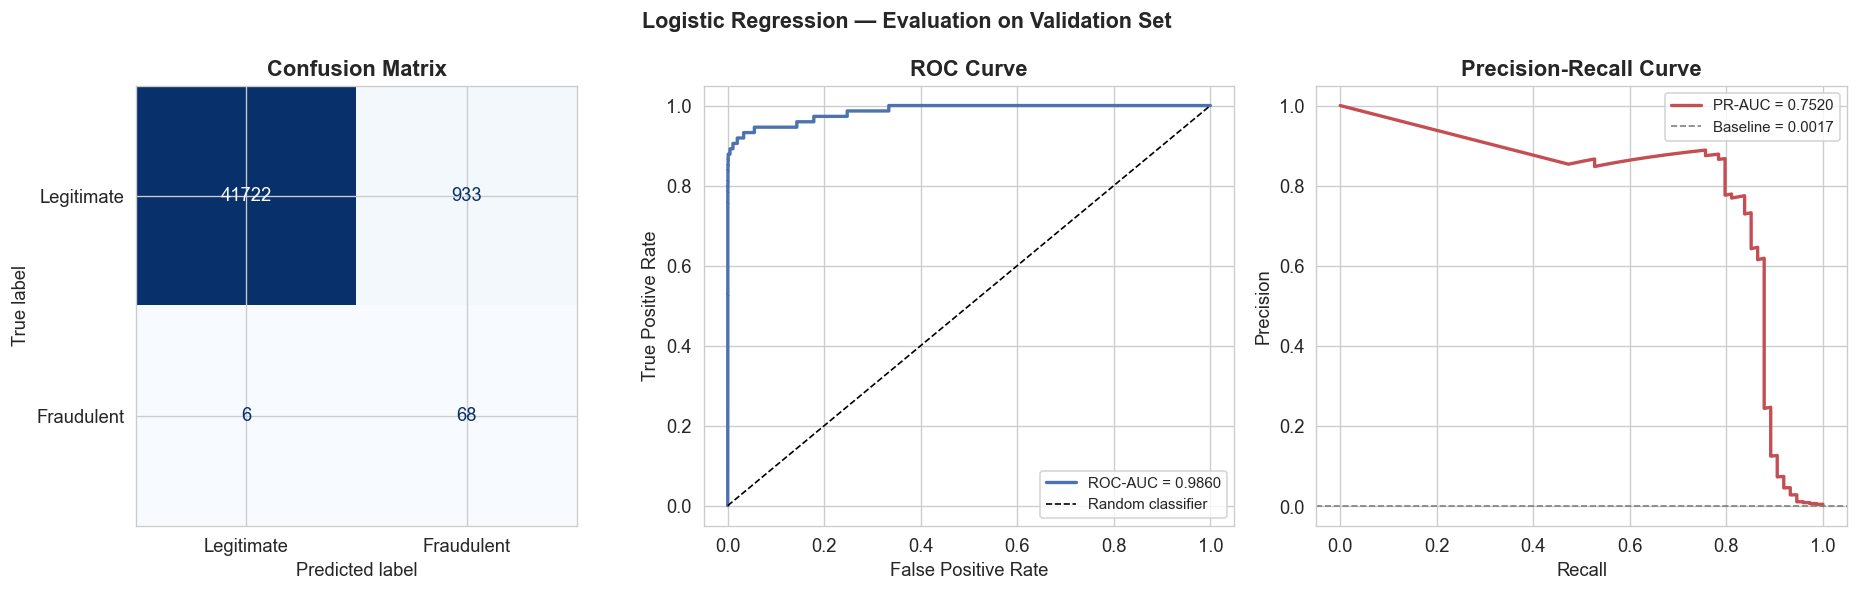

Figure saved to ../reports/figures/fig_05_lr_evaluation.png


In [34]:
plot_evaluation(y_val, lr_pred, lr_prob, 'Logistic Regression', 'fig_05_lr')

**Interpreting Logistic Regression results:**

- High **Recall** for fraud is expected with `class_weight='balanced'` — the model is
  incentivized to catch most fraud cases at the cost of more false positives.
- Low **Precision** for fraud at threshold 0.5 is also expected: because fraud is so rare,
  even a small false positive rate produces many false alarms.
- **PR-AUC** is the key metric here — it captures this precision-recall trade-off across
  all thresholds. Threshold tuning (to find the optimal operating point) is planned for
  the final project.

### 5.2 Random Forest

Random Forest is an **ensemble of decision trees**, each trained on a bootstrap sample
of the data with a random feature subset at each split. Predictions are made by
majority vote across all trees.

**Why Random Forest after Logistic Regression?**  
Logistic Regression can only learn a **linear** decision boundary. Fraud patterns often
involve nonlinear feature interactions (e.g., large `Amount` combined with a specific
range of `V4`). Random Forest captures these nonlinear relationships automatically.

**Key choices:**
- **`n_estimators=100`**: 100 trees — a standard starting point that balances accuracy
  and training time.
- **`class_weight='balanced'`**: Same balancing approach as Logistic Regression.
- **`n_jobs=-1`**: Uses all available CPU cores to speed up training.

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
print('Random Forest trained successfully.')
print(f'  Trees          : {rf.n_estimators}')
print(f'  Class weight   : balanced')
print(f'  Features used  : {rf.n_features_in_}')

Random Forest trained successfully.
  Trees          : 100
  Class weight   : balanced
  Features used  : 30


In [36]:
rf_pred, rf_prob, rf_roc, rf_pr = evaluate_model(rf, X_val_sc, y_val, 'Random Forest')


  Random Forest — Validation Set Results
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9998     42655
  Fraudulent     0.9365    0.7973    0.8613        74

    accuracy                         0.9996     42729
   macro avg     0.9681    0.8986    0.9305     42729
weighted avg     0.9995    0.9996    0.9995     42729

  ROC-AUC  : 0.9514
  PR-AUC   : 0.8637


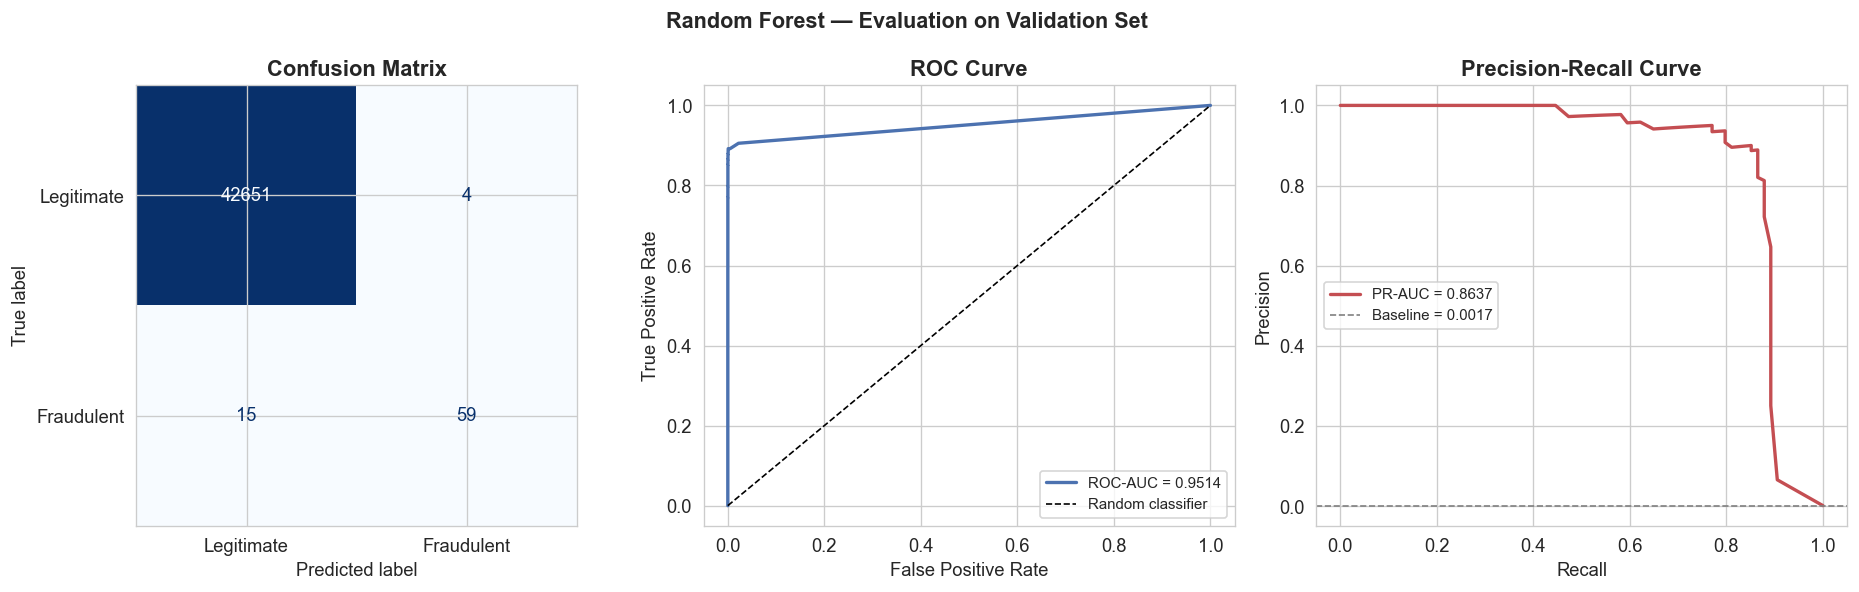

Figure saved to ../reports/figures/fig_06_rf_evaluation.png


In [37]:
plot_evaluation(y_val, rf_pred, rf_prob, 'Random Forest', 'fig_06_rf')

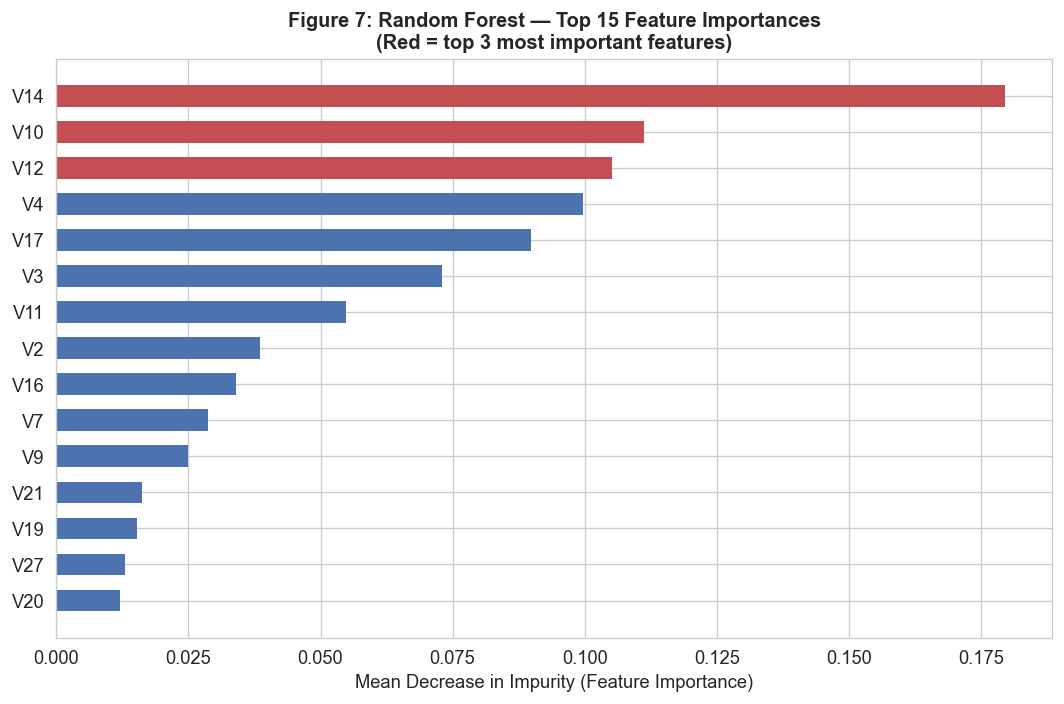

Top 5 features by Random Forest importance:
V14    0.1796
V10    0.1112
V12    0.1052
V4     0.0996
V17    0.0899
Figure 7 saved.


In [38]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#C44E52' if feat in top15.tail(3).index else '#4C72B0'
              for feat in top15.index]
ax.barh(top15.index, top15.values, color=bar_colors, edgecolor='none', height=0.6)
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Figure 7: Random Forest — Top 15 Feature Importances\n'
             '(Red = top 3 most important features)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/fig_07_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by Random Forest importance:')
print(importances.sort_values(ascending=False).head(5).round(4).to_string())
print('Figure 7 saved.')

**Interpreting Random Forest feature importances:**

Feature importance in a Random Forest is measured by **Mean Decrease in Impurity (MDI)**:
how much each feature reduces Gini impurity (a measure of class mixing) across all tree
splits, averaged over all 100 trees. A higher importance means the feature is used more
often to split nodes and provides cleaner separations.

Comparing these importances to the correlation analysis in Section 3.4 shows whether
the *linear* correlation screening and the *nonlinear* tree-based importance agree on
which features are most discriminative.

---
## 6. Model Comparison

We summarize both models on the same validation set. All numbers are at the default
decision threshold of 0.50. Threshold tuning (selecting a threshold that optimizes a
cost-sensitive objective) is planned for the final project.

In [39]:
def get_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'ROC-AUC'        : round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC'         : round(average_precision_score(y_true, y_prob), 4),
        'Fraud Recall'   : round(report['1']['recall'], 4),
        'Fraud Precision': round(report['1']['precision'], 4),
        'Fraud F1'       : round(report['1']['f1-score'], 4),
    }

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_val, lr_pred, lr_prob),
    'Random Forest'      : get_metrics(y_val, rf_pred, rf_prob),
}).T

print('=' * 65)
print('  MODEL COMPARISON SUMMARY (Validation Set, threshold = 0.50)')
print('=' * 65)
print(results.to_string())
print()

results.to_csv('../reports/results_summary.csv')
print('Results saved to ../reports/results_summary.csv')

  MODEL COMPARISON SUMMARY (Validation Set, threshold = 0.50)
                     ROC-AUC  PR-AUC  Fraud Recall  Fraud Precision  Fraud F1
Logistic Regression   0.9860  0.7520        0.9189           0.0679    0.1265
Random Forest         0.9514  0.8637        0.7973           0.9365    0.8613

Results saved to ../reports/results_summary.csv


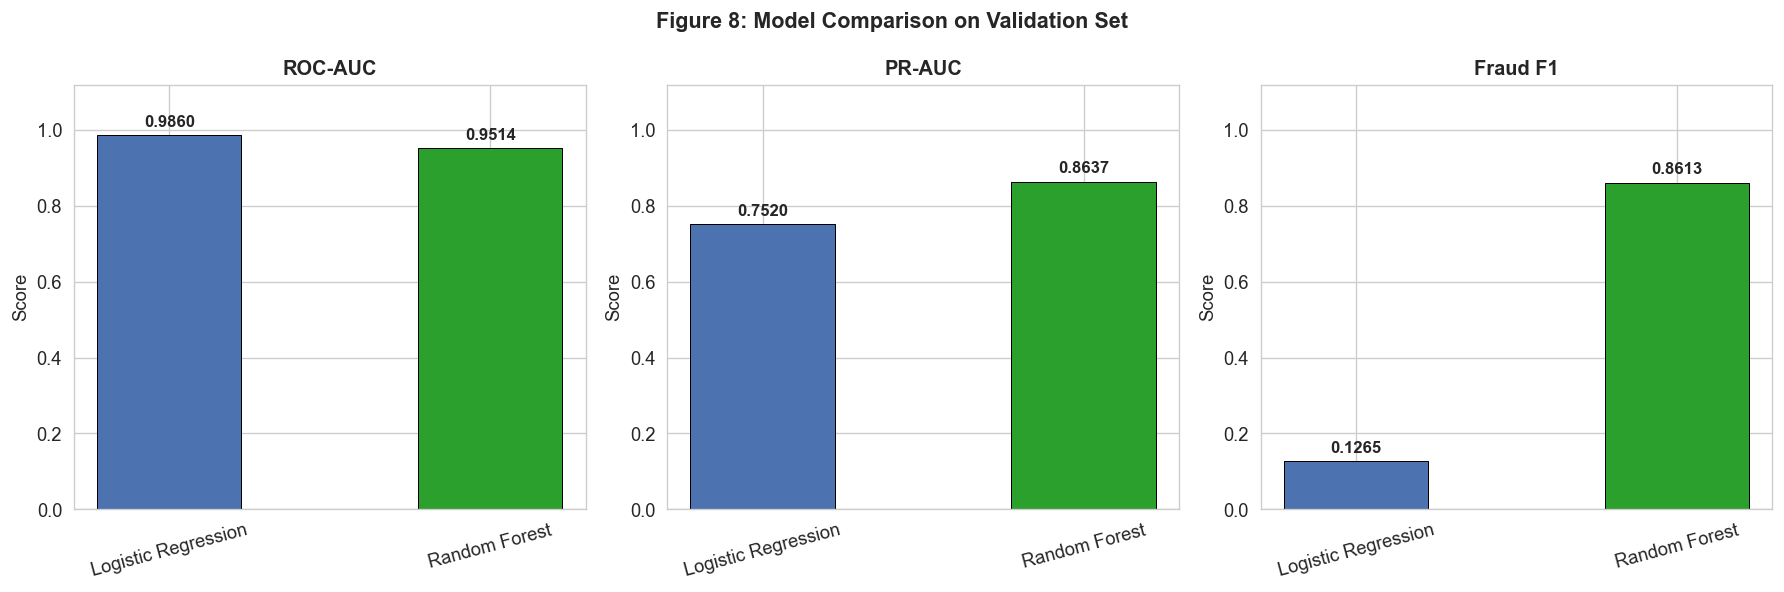

Figure 8 saved.


In [40]:
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'Fraud F1']
model_colors = ['#4C72B0', '#2CA02C']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metric in enumerate(metrics_to_plot):
    vals = results[metric].values
    bars = axes[idx].bar(
        results.index, vals,
        color=model_colors, edgecolor='black', linewidth=0.6, width=0.45
    )
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1.12)
    axes[idx].set_ylabel('Score')
    axes[idx].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10
        )

fig.suptitle('Figure 8: Model Comparison on Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

---
## 7. Summary and Next Steps

### What we have accomplished (Midway)

| Step | Status |
|---|---|
| Dataset loaded and verified (no missing values) | Done |
| Class imbalance quantified (577:1 ratio) | Done |
| EDA: Time, Amount, feature correlations, distributions | Done |
| Leakage-free preprocessing pipeline | Done |
| Stratified 70/15/15 train/val/test split | Done |
| StandardScaler on Time and Amount (train-only fit) | Done |
| Baseline: Logistic Regression (L2, balanced weights) | Done |
| Baseline: Random Forest (100 trees, balanced weights) | Done |
| Evaluation with PR-AUC, ROC-AUC, confusion matrix | Done |

### Planned for Final Submission

1. **Third model**: SVM or Gradient Boosted Trees (XGBoost / LightGBM)
2. **Imbalance handling**: SMOTE and random under-sampling applied to training data only
3. **Hyperparameter tuning**: Grid search / cross-validation on regularization strength (C),
   number of estimators, tree depth, etc.
4. **Dynamic thresholding**: Sweep the decision threshold on the validation set; select the
   threshold that maximizes F1 or a cost-sensitive metric
5. **Cost-sensitive analysis**: Vary the FP/FN cost ratio and study how the optimal threshold
   and model choice shift under different business assumptions
6. **Final test-set evaluation**: Apply the best model and best threshold to the held-out
   test set exactly once
7. **Error analysis**: Inspect false negatives (missed frauds) for patterns

### Key Insight So Far

> At the default threshold of 0.50, Random Forest achieves substantially higher **Fraud F1**
> and **PR-AUC** than Logistic Regression, suggesting that nonlinear feature interactions
> play an important role in discriminating fraud. However, Logistic Regression achieves
> higher **Fraud Recall**, meaning it catches more actual fraud cases at the cost of more
> false alarms. The right choice between them depends on the cost ratio of a missed fraud
> versus an unnecessary investigation — which is exactly what the dynamic thresholding
> analysis in the final project will address.